<a href="https://colab.research.google.com/github/harshpav/CELEBAL-EXCELLENCE-INTERNSHIP-_ASSIGNMENT/blob/main/week4_harsh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification: ANN, CNN, and Training Strategy Analysis

This notebook upgrades the CIFAR-10 assignment into a complete deep learning project. The focus is not only on model accuracy, but also on understanding why each architecture performs the way it does.

Project objectives:
- Explore the CIFAR-10 dataset with sample images and class distribution.
- Build a perceptron-style baseline, an ANN, a CNN, and an augmented CNN.
- Improve CNN generalization with Batch Normalization, Dropout, ImageDataGenerator, EarlyStopping, and ReduceLROnPlateau.
- Evaluate models using accuracy, loss, confusion matrices, classification reports, class-wise accuracy, and misclassified images.
- Add business-style interpretation and a professional conclusion.


## 1. Deep Learning Concepts Behind This Project

A perceptron is the basic unit of a neural network. It multiplies inputs by weights, adds a bias, and passes the result through an activation function.

An ANN or MLP stacks dense layers, but it treats every pixel as an independent feature after flattening the image. This usually limits performance on images because spatial relationships are lost.

A CNN keeps the image structure intact. Convolution filters learn local patterns, padding controls border handling, stride controls filter movement, and pooling reduces spatial size while preserving important features. These properties make CNNs much stronger for image classification.

Backpropagation is the training engine for all these models. It calculates how much each weight contributed to the error and updates the model through an optimizer such as Adam.


## 2. Import Libraries and Set Reproducibility

The imports are grouped by purpose. A fixed random seed makes the notebook more reproducible across reruns in Google Colab.


In [1]:
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks, layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
BATCH_SIZE = 64
EPOCHS = 12
BASELINE_EPOCHS = 5
TRANSFER_EPOCHS = 5

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 3. Load CIFAR-10 Dataset

CIFAR-10 contains 60,000 color images of size 32 x 32 x 3. There are 50,000 training images and 10,000 test images across 10 object classes.


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_train_flat = y_train.reshape(-1)
y_test_flat = y_test.reshape(-1)

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
Training labels: (50000, 1)
Testing labels: (10000, 1)


In [3]:
dataset_summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Images": [len(x_train), len(x_test)],
    "Image Shape": [x_train.shape[1:], x_test.shape[1:]],
    "Number of Classes": [len(class_names), len(class_names)]
})

dataset_summary


,Split,Images,Image Shape,Number of Classes
0,Train,50000,"(32, 32, 3)",10
1,Test,10000,"(32, 32, 3)",10


## 4. Dataset Exploration

A quick visual inspection helps us understand the difficulty of the task. CIFAR-10 images are small, colorful, and sometimes ambiguous, so a good model must learn compact visual patterns instead of relying on high-resolution details.


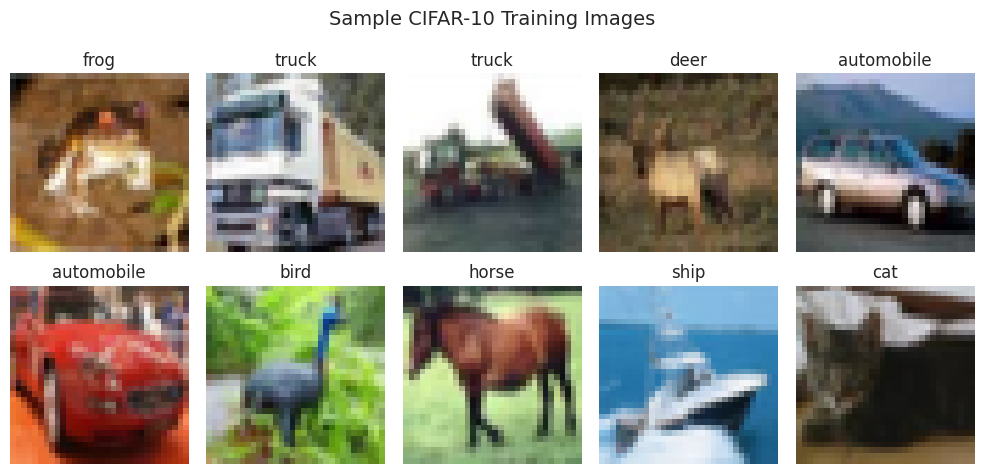

In [4]:
plt.figure(figsize=(10, 5))
for index in range(10):
    plt.subplot(2, 5, index + 1)
    plt.imshow(x_train[index])
    plt.title(class_names[y_train_flat[index]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Training Images", fontsize=14)
plt.tight_layout()
plt.show()


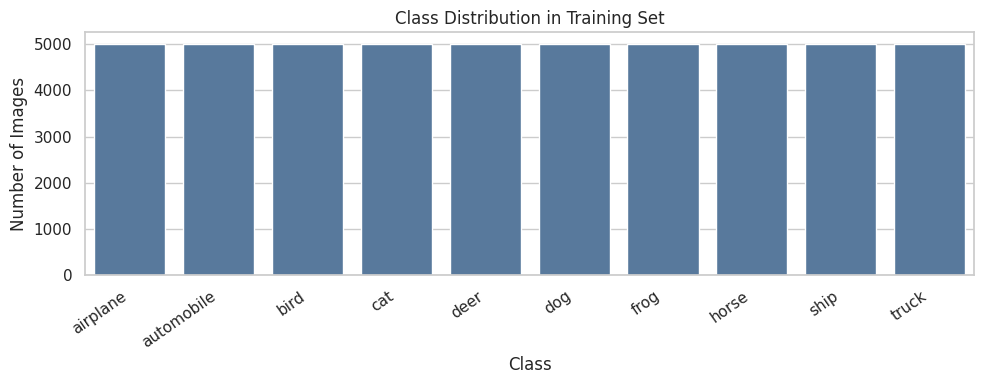

,Training Images
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000
truck,5000


In [5]:
class_distribution = pd.Series(y_train_flat).value_counts().sort_index()
class_distribution.index = class_names

plt.figure(figsize=(10, 4))
sns.barplot(
    x=class_distribution.index,
    y=class_distribution.values,
    color="#4C78A8"
)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

class_distribution.to_frame(name="Training Images")


## 5. Preprocessing and Train-Validation Split

Pixel values are normalized from 0-255 to 0-1. The original image format is used for CNNs, while flattened vectors are created for ANN-based models.

A stratified validation split is used so every class remains represented in both training and validation data.


In [6]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_img, x_val_img, y_train_split, y_val_split = train_test_split(
    x_train_norm,
    y_train_flat,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_flat
)

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)
x_train_flat_split = x_train_img.reshape(len(x_train_img), -1)
x_val_flat = x_val_img.reshape(len(x_val_img), -1)

print("Image train split:", x_train_img.shape)
print("Image validation split:", x_val_img.shape)
print("Flat train split:", x_train_flat_split.shape)
print("Flat validation split:", x_val_flat.shape)


Image train split: (45000, 32, 32, 3)
Image validation split: (5000, 32, 32, 3)
Flat train split: (45000, 3072)
Flat validation split: (5000, 3072)


## 6. Utility Functions

The helper functions below keep the notebook clean and reduce repeated code. They handle callbacks, training time tracking, evaluation, confusion matrices, learning curves, and misclassified image visualization.


In [ ]:
training_times = {}
evaluation_rows = []
model_reports = {}
model_predictions = {}


def make_callbacks(model_name):
    """Create fresh callbacks for each model training run."""
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]


def train_model(model, model_name, *fit_args, **fit_kwargs):
    """Train a model and store wall-clock training time."""
    start_time = time.time()
    history = model.fit(*fit_args, **fit_kwargs)
    training_times[model_name] = (time.time() - start_time) / 60
    return history


def trainable_parameter_count(model):
    """Return the number of trainable parameters in a Keras model."""
    return int(np.sum([np.prod(weight.shape) for weight in model.trainable_weights]))


def evaluate_model(model, model_name, x_data, y_true):
    """Evaluate a model and print a classification report."""
    test_loss, test_accuracy = model.evaluate(x_data, y_true, verbose=0)
    predictions = np.argmax(model.predict(x_data, verbose=0), axis=1)
    report = classification_report(
        y_true,
        predictions,
        target_names=class_names,
        zero_division=0,
        output_dict=True
    )

    print(f"{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Test Accuracy: {test_accuracy:.4f}\n")
    print(classification_report(
        y_true,
        predictions,
        target_names=class_names,
        zero_division=0
    ))

    row = {
        "Model": model_name,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy,
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"],
        "Trainable Parameters": trainable_parameter_count(model),
        "Epochs Run": np.nan,
        "Training Time (min)": training_times.get(model_name, np.nan)
    }

    model_reports[model_name] = report
    model_predictions[model_name] = predictions
    return row, predictions, report


In [ ]:
def plot_training_curves(history, title):
    """Plot training and validation accuracy/loss curves."""
    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["accuracy"], marker="o", label="Train")
    plt.plot(epochs, history.history["val_accuracy"], marker="o", label="Validation")
    plt.title(f"{title}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["loss"], marker="o", label="Train")
    plt.plot(epochs, history.history["val_loss"], marker="o", label="Validation")
    plt.title(f"{title}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a labeled confusion matrix."""
    matrix = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()


def show_misclassified_images(images, y_true, y_pred, title, max_images=10):
    """Display misclassified test images with actual and predicted labels."""
    wrong_indices = np.where(y_true != y_pred)[0][:max_images]

    if len(wrong_indices) == 0:
        print("No misclassified images found.")
        return

    plt.figure(figsize=(14, 6))
    for plot_index, image_index in enumerate(wrong_indices):
        plt.subplot(2, 5, plot_index + 1)
        plt.imshow(images[image_index])
        actual = class_names[y_true[image_index]]
        predicted = class_names[y_pred[image_index]]
        plt.title(f"Actual: {actual}\nPred: {predicted}", fontsize=10)
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


## 7. Perceptron-Style Baseline

This baseline uses a single dense softmax layer. It is intentionally simple and helps show why deeper networks are needed for image data.


In [9]:
baseline_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(10, activation="softmax")
], name="perceptron_style_baseline")

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = train_model(
    baseline_model,
    "Perceptron Baseline",
    x_train_flat_split,
    y_train_split,
    epochs=BASELINE_EPOCHS,
    batch_size=128,
    validation_data=(x_val_flat, y_val_split),
    callbacks=make_callbacks("Perceptron Baseline"),
    verbose=1
)


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3122 - loss: 1.9378 - val_accuracy: 0.3142 - val_loss: 1.9038 - learning_rate: 0.0010
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3566 - loss: 1.8361 - val_accuracy: 0.3278 - val_loss: 1.8717 - learning_rate: 0.0010
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3680 - loss: 1.8075 - val_accuracy: 0.3354 - val_loss: 1.8554 - learning_rate: 0.0010
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3763 - loss: 1.7899 - val_accuracy: 0.3410 - val_loss: 1.8457 - learning_rate: 0.0010
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3813 - loss: 1.7774 - val_accuracy: 0.3436 - val_loss: 1.8393 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


In [10]:
baseline_eval, baseline_pred, baseline_report = evaluate_model(
    baseline_model,
    "Perceptron Baseline",
    x_test_flat,
    y_test_flat
)
baseline_eval["Epochs Run"] = len(baseline_history.history["loss"])
evaluation_rows.append(baseline_eval)


Perceptron Baseline Test Loss: 1.8341
Perceptron Baseline Test Accuracy: 0.3423

              precision    recall  f1-score   support

    airplane       0.50      0.27      0.35      1000
  automobile       0.52      0.43      0.47      1000
        bird       0.38      0.06      0.10      1000
         cat       0.18      0.75      0.29      1000
        deer       0.42      0.20      0.28      1000
         dog       0.42      0.07      0.13      1000
        frog       0.44      0.29      0.35      1000
       horse       0.50      0.35      0.41      1000
        ship       0.43      0.57      0.49      1000
       truck       0.45      0.44      0.44      1000

    accuracy                           0.34     10000
   macro avg       0.42      0.34      0.33     10000
weighted avg       0.42      0.34      0.33     10000



## 8. ANN Model

The ANN uses fully connected layers with ReLU activations and Dropout. It can learn non-linear combinations of pixels, but it still receives flattened input, so it cannot directly use spatial relationships such as edges, corners, and textures.


In [11]:
def build_ann_model():
    model = models.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(1024, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(10, activation="softmax")
    ], name="ann_relu_dropout")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


ann_model = build_ann_model()
ann_model.summary()


Model: "ann_relu_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
ann_history = train_model(
    ann_model,
    "ANN",
    x_train_flat_split,
    y_train_split,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_flat, y_val_split),
    callbacks=make_callbacks("ANN"),
    verbose=1
)


Epoch 1/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 69ms/step - accuracy: 0.2301 - loss: 2.0746 - val_accuracy: 0.2956 - val_loss: 1.9224 - learning_rate: 0.0010
Epoch 2/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 83ms/step - accuracy: 0.2778 - loss: 1.9446 - val_accuracy: 0.3298 - val_loss: 1.8774 - learning_rate: 0.0010
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.2931 - loss: 1.9099 - val_accuracy: 0.3256 - val_loss: 1.8556 - learning_rate: 0.0010
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 68ms/step - accuracy: 0.3022 - loss: 1.8877 - val_accuracy: 0.3204 - val_loss: 1.8553 - learning_rate: 0.0010
Epoch 5/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.3055 - loss: 1.8751 - val_accuracy: 0.3426 - val_loss: 1.8297 - learning_rate: 0.0010
Epoch 6/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.3148 - loss: 1.8594 - val_accuracy: 0.3302 - val_loss: 1.8279 - learning_rate: 0.0010
Epoch 7/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3213 - l

In [13]:
ann_eval, ann_pred, ann_report = evaluate_model(
    ann_model,
    "ANN",
    x_test_flat,
    y_test_flat
)
ann_eval["Epochs Run"] = len(ann_history.history["loss"])
evaluation_rows.append(ann_eval)

ann_test_loss = ann_eval["Test Loss"]
ann_test_acc = ann_eval["Test Accuracy"]


ANN Test Loss: 1.7362
ANN Test Accuracy: 0.3958

              precision    recall  f1-score   support

    airplane       0.60      0.34      0.43      1000
  automobile       0.52      0.52      0.52      1000
        bird       0.28      0.14      0.19      1000
         cat       0.24      0.38      0.30      1000
        deer       0.31      0.33      0.32      1000
         dog       0.52      0.15      0.24      1000
        frog       0.33      0.68      0.44      1000
       horse       0.49      0.41      0.45      1000
        ship       0.53      0.48      0.51      1000
       truck       0.45      0.52      0.48      1000

    accuracy                           0.40     10000
   macro avg       0.43      0.40      0.39     10000
weighted avg       0.43      0.40      0.39     10000



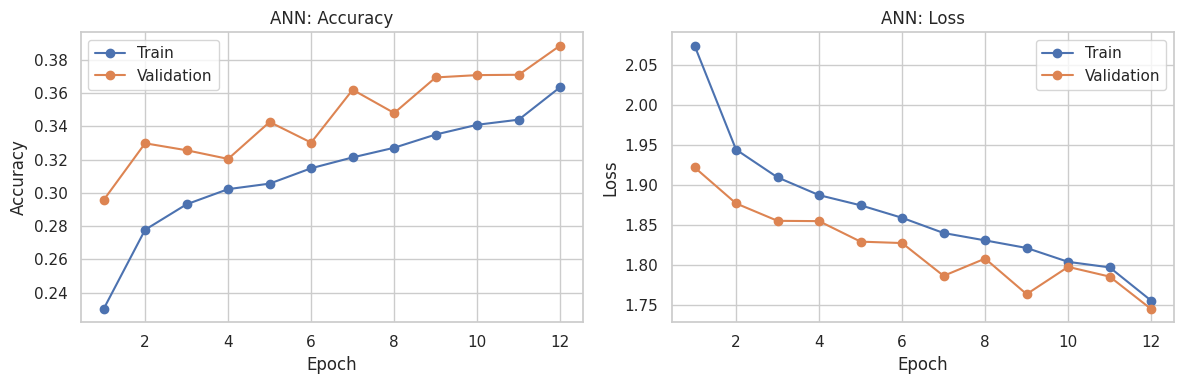

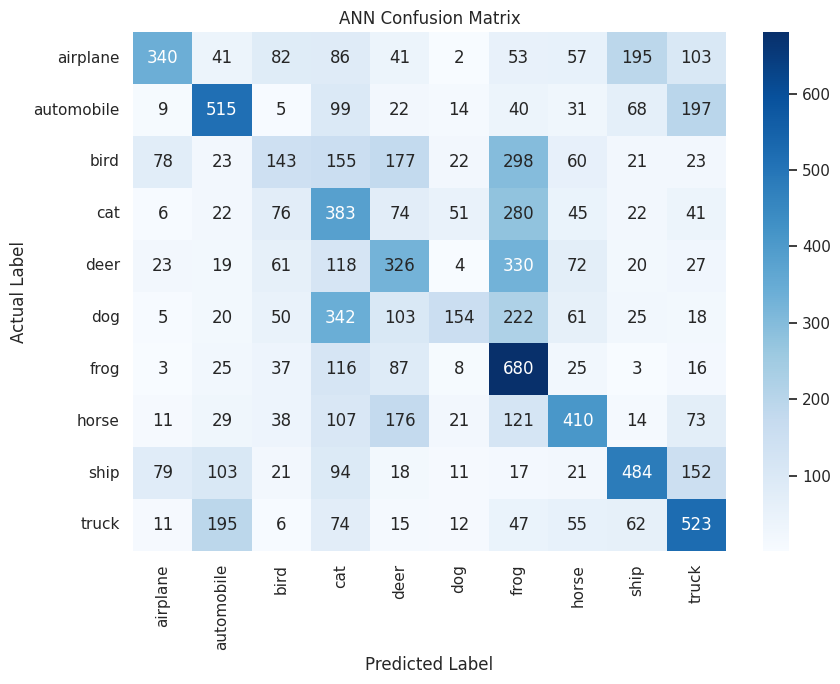

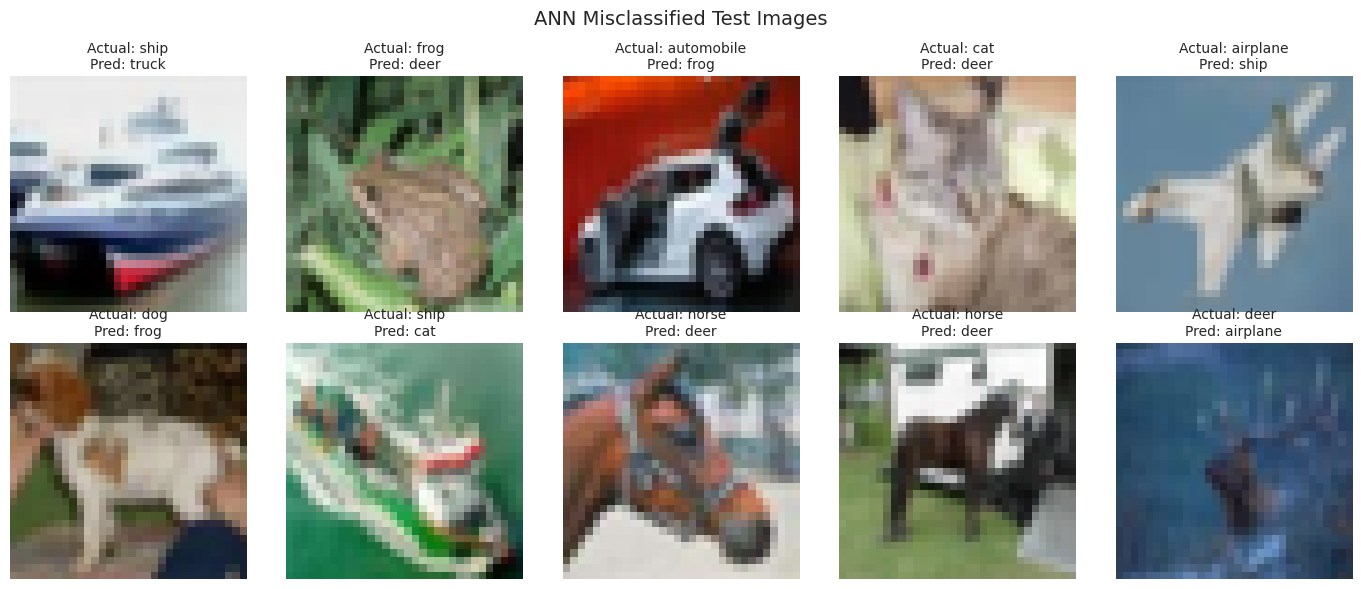

In [14]:
plot_training_curves(ann_history, "ANN")
plot_confusion_matrix(y_test_flat, ann_pred, "ANN Confusion Matrix")
show_misclassified_images(
    x_test,
    y_test_flat,
    ann_pred,
    "ANN Misclassified Test Images"
)


## 9. CNN Model with Batch Normalization and Dropout

The CNN is the main image-focused model. Batch Normalization stabilizes training, MaxPooling reduces spatial dimensions, and Dropout reduces overfitting. Padding is set to `same` so edge information is preserved through convolution blocks.


In [15]:
def build_cnn_model(model_name="cnn_batchnorm_dropout"):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.40),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(10, activation="softmax")
    ], name=model_name)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


cnn_model = build_cnn_model()
cnn_model.summary()


Model: "cnn_batchnorm_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
cnn_history = train_model(
    cnn_model,
    "CNN",
    x_train_img,
    y_train_split,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_img, y_val_split),
    callbacks=make_callbacks("CNN"),
    verbose=1
)


Epoch 1/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 357s 499ms/step - accuracy: 0.4225 - loss: 1.7053 - val_accuracy: 0.5040 - val_loss: 1.3930 - learning_rate: 0.0010
Epoch 2/12
384/704 ━━━━━━━━━━━━━━━━━━━━ 2:39 497ms/step - accuracy: 0.5529 - loss: 1.2541

In [ ]:
cnn_eval, cnn_pred, cnn_report = evaluate_model(
    cnn_model,
    "CNN",
    x_test_norm,
    y_test_flat
)
cnn_eval["Epochs Run"] = len(cnn_history.history["loss"])
evaluation_rows.append(cnn_eval)

cnn_test_loss = cnn_eval["Test Loss"]
cnn_test_acc = cnn_eval["Test Accuracy"]


In [ ]:
plot_training_curves(cnn_history, "CNN")
plot_confusion_matrix(y_test_flat, cnn_pred, "CNN Confusion Matrix")
show_misclassified_images(
    x_test,
    y_test_flat,
    cnn_pred,
    "CNN Misclassified Test Images"
)


## 10. Data Augmentation with ImageDataGenerator

Data augmentation makes the training set more diverse by applying small random transformations. This helps the CNN generalize better because the model cannot memorize the exact training images.

The validation set is kept unaugmented so validation performance reflects real images rather than artificially changed ones.


In [ ]:
image_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

augmented_preview = image_datagen.flow(
    x_train_img[:1],
    y_train_split[:1],
    batch_size=1,
    seed=SEED
)

plt.figure(figsize=(10, 3))
for index in range(6):
    augmented_image, _ = next(augmented_preview)
    plt.subplot(1, 6, index + 1)
    plt.imshow(np.clip(augmented_image[0], 0, 1))
    plt.axis("off")

plt.suptitle("ImageDataGenerator Augmentation Preview", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
aug_train_generator = image_datagen.flow(
    x_train_img,
    y_train_split,
    batch_size=BATCH_SIZE,
    seed=SEED
)

aug_cnn_model = build_cnn_model(model_name="cnn_with_imagedatagenerator")
aug_cnn_model.summary()


In [ ]:
aug_history = train_model(
    aug_cnn_model,
    "CNN + ImageDataGenerator",
    aug_train_generator,
    epochs=EPOCHS,
    validation_data=(x_val_img, y_val_split),
    callbacks=make_callbacks("CNN + ImageDataGenerator"),
    verbose=1
)


In [ ]:
aug_eval, aug_pred, aug_report = evaluate_model(
    aug_cnn_model,
    "CNN + ImageDataGenerator",
    x_test_norm,
    y_test_flat
)
aug_eval["Epochs Run"] = len(aug_history.history["loss"])
evaluation_rows.append(aug_eval)

aug_test_loss = aug_eval["Test Loss"]
aug_test_acc = aug_eval["Test Accuracy"]
aug_acc = aug_test_acc


In [ ]:
plot_training_curves(aug_history, "CNN + ImageDataGenerator")
plot_confusion_matrix(
    y_test_flat,
    aug_pred,
    "CNN + ImageDataGenerator Confusion Matrix"
)


## 11. Optional Professional Upgrade: Transfer Learning with MobileNetV2

Transfer learning is common in real projects because pretrained CNNs already understand useful visual patterns. MobileNetV2 is used as a frozen feature extractor, then a small classifier head is trained for CIFAR-10.




In [ ]:
try:
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(96, 96, 3)
    )
    transfer_weight_source = "ImageNet pretrained weights"
    base_model.trainable = False
except Exception as error:
    print("ImageNet weights could not be loaded.")
    print("Fallback reason:", error)
    base_model = MobileNetV2(
        weights=None,
        include_top=False,
        input_shape=(96, 96, 3)
    )
    transfer_weight_source = "Randomly initialized fallback"
    base_model.trainable = True

transfer_inputs = layers.Input(shape=(32, 32, 3))
x = layers.Resizing(96, 96)(transfer_inputs)
x = layers.Lambda(
    lambda image: preprocess_input(image * 255.0),
    name="mobilenetv2_preprocess"
)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.20)(x)
transfer_outputs = layers.Dense(10, activation="softmax")(x)

transfer_model = tf.keras.Model(
    transfer_inputs,
    transfer_outputs,
    name="mobilenetv2_transfer_learning"
)

transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()
print("Transfer learning source:", transfer_weight_source)


In [ ]:
transfer_history = train_model(
    transfer_model,
    "Transfer Learning",
    x_train_img,
    y_train_split,
    epochs=TRANSFER_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_img, y_val_split),
    callbacks=make_callbacks("Transfer Learning"),
    verbose=1
)


In [ ]:
transfer_eval, transfer_pred, transfer_report = evaluate_model(
    transfer_model,
    "Transfer Learning",
    x_test_norm,
    y_test_flat
)
transfer_eval["Epochs Run"] = len(transfer_history.history["loss"])
evaluation_rows.append(transfer_eval)

transfer_test_loss = transfer_eval["Test Loss"]
transfer_acc = transfer_eval["Test Accuracy"]


In [ ]:
plot_training_curves(transfer_history, "Transfer Learning")


## 12. Combined Learning Curve Comparison

The combined validation curves show how each strategy behaves during training. A model with a strong validation curve and a small train-validation gap is usually more reliable than a model that only memorizes training data.


In [ ]:
def plot_combined_metric(histories, metric, title, ylabel):
    plt.figure(figsize=(10, 5))
    for model_name, history in histories.items():
        values = history.history[metric]
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, marker="o", linewidth=2, label=model_name)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


history_map = {
    "Perceptron": baseline_history,
    "ANN": ann_history,
    "CNN": cnn_history,
    "CNN + Aug": aug_history,
    "Transfer": transfer_history
}

plot_combined_metric(
    history_map,
    "val_accuracy",
    "Validation Accuracy Comparison",
    "Validation Accuracy"
)
plot_combined_metric(
    history_map,
    "val_loss",
    "Validation Loss Comparison",
    "Validation Loss"
)


## 13. Model Comparison Table

The comparison table brings together accuracy, F1-score, trainable parameters, number of epochs actually run, and training time. This makes the evaluation more balanced than accuracy alone.


In [ ]:
strategy_map = {
    "Perceptron Baseline": "Single dense softmax layer",
    "ANN": "Dense network with ReLU and Dropout",
    "CNN": "Convolutions with BatchNorm, MaxPooling, and Dropout",
    "CNN + ImageDataGenerator": "CNN trained with real-time image augmentation",
    "Transfer Learning": f"MobileNetV2 feature extractor ({transfer_weight_source})"
}

comparison = pd.DataFrame(evaluation_rows)
comparison["Training Strategy"] = comparison["Model"].map(strategy_map)
comparison = comparison[
    [
        "Model",
        "Training Strategy",
        "Test Accuracy",
        "Test Loss",
        "Macro F1",
        "Weighted F1",
        "Trainable Parameters",
        "Epochs Run",
        "Training Time (min)"
    ]
].sort_values("Test Accuracy", ascending=False)

comparison.reset_index(drop=True)


## 14. Class-Wise Accuracy Analysis

Overall accuracy can hide weak classes. Class-wise accuracy shows which categories each model handles well and which categories still need improvement.


In [ ]:
def get_classwise_accuracy(y_true, y_pred, model_name):
    matrix = confusion_matrix(y_true, y_pred)
    class_totals = matrix.sum(axis=1)
    class_accuracy = np.divide(
        np.diag(matrix),
        class_totals,
        out=np.zeros_like(class_totals, dtype=float),
        where=class_totals != 0
    )

    return pd.DataFrame({
        "Model": model_name,
        "Class": class_names,
        "Class Accuracy": class_accuracy
    })


classwise_accuracy = pd.concat([
    get_classwise_accuracy(y_test_flat, ann_pred, "ANN"),
    get_classwise_accuracy(y_test_flat, cnn_pred, "CNN"),
    get_classwise_accuracy(y_test_flat, aug_pred, "CNN + ImageDataGenerator"),
    get_classwise_accuracy(y_test_flat, transfer_pred, "Transfer Learning")
], ignore_index=True)

classwise_pivot = classwise_accuracy.pivot(
    index="Class",
    columns="Model",
    values="Class Accuracy"
)

classwise_pivot


In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    classwise_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Class-Wise Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


## 15. Overfitting and Generalization Analysis

The train-validation gap compares final training accuracy with final validation accuracy. A large gap suggests overfitting. Data augmentation and Dropout usually reduce this gap by making the model less dependent on exact training examples.


In [ ]:
def summarize_generalization(history, model_name):
    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    return {
        "Model": model_name,
        "Final Train Accuracy": final_train_acc,
        "Final Validation Accuracy": final_val_acc,
        "Accuracy Gap": final_train_acc - final_val_acc,
        "Final Train Loss": final_train_loss,
        "Final Validation Loss": final_val_loss,
        "Loss Gap": final_val_loss - final_train_loss
    }


generalization_summary = pd.DataFrame([
    summarize_generalization(baseline_history, "Perceptron Baseline"),
    summarize_generalization(ann_history, "ANN"),
    summarize_generalization(cnn_history, "CNN"),
    summarize_generalization(aug_history, "CNN + ImageDataGenerator"),
    summarize_generalization(transfer_history, "Transfer Learning")
]).sort_values("Final Validation Accuracy", ascending=False)

generalization_summary


## 16. Business Insights and Interpretation

1. For image classification problems, CNN-based models are a better production starting point than ANN models because they preserve spatial structure and learn reusable visual features.

2. ANN performance is useful as a baseline, but its lower class-wise accuracy on visually similar categories shows why flattening is a weak strategy for real image products.

3. Data augmentation is valuable when the dataset is limited or when the model may see slightly shifted, zoomed, or flipped images after deployment.

4. Confusion matrix patterns can guide data collection. For example, if the model confuses cats and dogs, collecting more diverse examples of those classes may improve performance.

5. Transfer learning is often attractive in business settings because it can deliver strong performance with fewer task-specific training epochs.

6. The final model should not be chosen by accuracy alone. Training time, parameter count, class-wise stability, and misclassification cost also matter.


## 17. Final Conclusion

This project demonstrates the full progression from a simple perceptron-style model to ANN, CNN, augmented CNN, and transfer learning. The ANN can learn non-linear pixel patterns, but it loses image structure after flattening. The CNN performs better because it learns local features through convolution, pooling, and hierarchical representation learning.

The augmented CNN improves generalization by exposing the model to more varied training examples, while callbacks such as EarlyStopping and ReduceLROnPlateau make training more efficient and stable. Transfer learning adds an industry-level strategy by reusing pretrained visual features.

Overall, CNN-based architectures are the most suitable choice for CIFAR-10 because they align with the structure of image data. The evaluation using classification reports, confusion matrices, class-wise accuracy, learning curves, and misclassified examples makes the notebook a complete deep learning project rather than a simple training script.
